In [1]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/nike/nike_data.csv')

In [3]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-05-31,11.503123,4713.0,342.0,13250.0,4557.0,8693.0,-3.23,0.15
1,1,2009-08-31,11.216619,4799.0,513.0,13191.0,4100.0,9091.0,-3.98,0.16
2,2,2009-11-30,13.202310,4405.0,375.0,13358.0,4134.0,9224.0,-3.13,0.12
3,3,2010-02-28,13.810738,4733.0,497.0,13576.0,4147.0,9429.0,0.11,0.11
4,4,2010-05-31,14.846562,5077.0,522.0,14419.0,4665.0,9754.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
60,60,2024-05-31,92.213409,12606.0,1500.0,38110.0,23680.0,14430.0,2.90,5.33
61,61,2024-08-31,81.149361,11589.0,1051.0,37867.0,23923.0,13944.0,3.04,5.33
62,62,2024-11-30,77.060097,12354.0,1163.0,37959.0,23922.0,14037.0,2.72,4.83
63,63,2025-02-28,78.102379,11269.0,794.0,37793.0,23786.0,14007.0,2.53,4.33


In [4]:
# create column assets_liabilities_ratio
#data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop unnecessary columns
data = data.drop(columns=['Unnamed: 0'])

In [5]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-05-31,71.240829,10184.0,989.0,23717.0,14677.0,9040.0,1.93,2.42
41,2019-08-31,78.239571,10660.0,1367.0,26249.0,17049.0,9200.0,2.24,2.40
42,2019-11-30,86.789429,10326.0,1115.0,26602.0,17251.0,9351.0,2.80,1.83
43,2020-02-29,83.204178,10104.0,847.0,26220.0,17175.0,9045.0,3.35,1.55
44,2020-05-31,91.997429,6313.0,-790.0,31342.0,23287.0,8055.0,1.28,0.05
45,2020-08-31,104.649994,10594.0,1518.0,33258.0,24034.0,9224.0,-7.50,0.09
46,2020-11-30,125.984024,11243.0,1251.0,34836.0,24196.0,10640.0,-1.41,0.09
47,2021-02-28,126.569283,10357.0,1449.0,36185.0,24254.0,11931.0,-1.02,0.09
48,2021-05-31,128.405518,12344.0,1509.0,37740.0,24973.0,12767.0,1.76,0.07
49,2021-08-31,155.272079,12248.0,1874.0,37917.0,23574.0,14343.0,12.24,0.10


In [6]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 6    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
n = len(df)

# exponential weights: more recent quarters get larger weight
K=8
weights = np.exp(np.linspace(K, 0, n))  
weights /= weights.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = df[col].pct_change()
    growth_rates[col] = np.average(gr.dropna(), weights=weights[1:])  # skip first NaN


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
#future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6998/2512984096.py:46: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [7]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
n_bt = len(df_bt)

# exponential weights: more recent quarters get larger weight
K=8
weights_bt = np.exp(np.linspace(K, 0, n_bt))  
weights_bt /= weights_bt.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = df_bt[col].pct_change()
    growth_rates_bt[col] = np.average(gr_bt.dropna(), weights=weights_bt[1:])  # skip first NaN

# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr_bt) ** i for i in range(1, FUTURE_PERIODS+1)]

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6998/2427448722.py:41: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [8]:
growth_rates_bt

{'revenue_musd': np.float64(0.018940405061084686),
 'net_income_musd': np.float64(0.08867424503911396),
 'total_assets_musd': np.float64(0.014305429236849979),
 'total_liabilities_musd': np.float64(0.011005883217064813),
 'share_holder_equity_musd': np.float64(0.016460112431445236)}

In [9]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



20:30:10 - cmdstanpy - INFO - Chain [1] start processing
20:30:10 - cmdstanpy - INFO - Chain [1] done processing


           ds         yhat   yhat_lower   yhat_upper           y
59 2024-02-29    91.581550    82.495756   101.256591  100.469452
60 2024-05-31    91.055740    81.681101   100.062716   92.213409
61 2024-08-31    80.359860    70.237233    89.771826   81.149361
62 2024-11-30    90.805325    81.892482    99.940168   77.060097
63 2025-02-28    86.789531    77.217928    96.675559   78.102379
64 2025-05-31    71.609546    61.689943    81.021019   59.878819
65 2025-09-30  -639.898764  -648.972790  -629.790987         NaN
66 2025-12-31  -747.745938  -757.609783  -738.107503         NaN
67 2026-03-31  1254.557315  1244.773315  1263.668611         NaN
68 2026-06-30  1804.169123  1794.337203  1814.442590         NaN
69 2026-09-30  -636.381018  -646.223018  -626.586963         NaN
70 2026-12-31  -776.563274  -786.811725  -766.871690         NaN


In [10]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

20:30:10 - cmdstanpy - INFO - Chain [1] start processing
20:30:10 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
55 2023-02-28  104.995183   96.280477  114.165673  113.369247
56 2023-05-31   95.239461   86.220971  103.287743  100.743118
57 2023-08-31   93.881389   85.221699  103.575390   97.665871
58 2023-11-30  104.781118   95.710070  113.636394  106.240669
59 2024-02-29   98.116275   89.314523  106.811103  100.469452
60 2024-05-31   97.036688   88.255948  105.675461   92.213409
61 2024-09-30 -294.069577 -302.743750 -285.545564         NaN
62 2024-12-31 -243.922832 -253.031313 -235.752476         NaN
63 2025-03-31  504.039243  494.831998  512.844088         NaN
64 2025-06-30  864.924659  856.209536  873.843903         NaN
65 2025-09-30 -276.562005 -285.631647 -267.896943         NaN
66 2025-12-31 -255.002391 -263.549650 -245.888833         NaN


In [11]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 5.669458418395932
RMSE: 56.55727727989135
R²: 0.9618266350768013
           ds         yhat   yhat_lower   yhat_upper           y  is_future
59 2024-02-29    91.581550    82.495756   101.256591  100.469452      False
60 2024-05-31    91.055740    81.681101   100.062716   92.213409      False
61 2024-08-31    80.359860    70.237233    89.771826   81.149361      False
62 2024-11-30    90.805325    81.892482    99.940168   77.060097      False
63 2025-02-28    86.789531    77.217928    96.675559   78.102379      False
64 2025-05-31    71.609546    61.689943    81.021019   59.878819      False
65 2025-09-30  -639.898764  -648.972790  -629.790987         NaN       True
66 2025-12-31  -747.745938  -757.609783  -738.107503         NaN       True
67 2026-03-31  1254.557315  1244.773315  1263.668611         NaN       True
68 2026-06-30  1804.169123  1794.337203  1814.442590         NaN       True
69 2026-09-30  -636.381018  -646.223018  -626.586963         NaN       True
70 2026-12-31  -77

In [12]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 5.057977763032844
RMSE: 48.1166904098321
R²: 0.9692339055289197
           ds        yhat  yhat_lower  yhat_upper           y  is_future
55 2023-02-28  104.995183   96.280477  114.165673  113.369247      False
56 2023-05-31   95.239461   86.220971  103.287743  100.743118      False
57 2023-08-31   93.881389   85.221699  103.575390   97.665871      False
58 2023-11-30  104.781118   95.710070  113.636394  106.240669      False
59 2024-02-29   98.116275   89.314523  106.811103  100.469452      False
60 2024-05-31   97.036688   88.255948  105.675461   92.213409      False
61 2024-09-30 -294.069577 -302.743750 -285.545564         NaN       True
62 2024-12-31 -243.922832 -253.031313 -235.752476         NaN       True
63 2025-03-31  504.039243  494.831998  512.844088         NaN       True
64 2025-06-30  864.924659  856.209536  873.843903         NaN       True
65 2025-09-30 -276.562005 -285.631647 -267.896943         NaN       True
66 2025-12-31 -255.002391 -263.549650 -245.888833      

In [13]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
49 2021-08-31  155.272079  145.460126        9.811954           6.3%
50 2021-11-30  159.513474  131.536304       27.977170          17.5%
51 2022-02-28  128.933548  130.933947        2.000399           1.6%
52 2022-05-31  112.476875  127.888562       15.411687          13.7%
53 2022-08-31  100.991386  119.146124       18.154738          18.0%
54 2022-11-30  104.364174  117.655587       13.291413          12.7%
55 2023-02-28  113.369247  104.995183        8.374065           7.4%
56 2023-05-31  100.743118   95.239461        5.503657           5.5%
57 2023-08-31   97.665871   93.881389        3.784481           3.9%
58 2023-11-30  106.240669  104.781118        1.459551           1.4%
59 2024-02-29  100.469452   98.116275        2.353177           2.3%
60 2024-05-31   92.213409   97.036688        4.823279           5.2%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6998/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


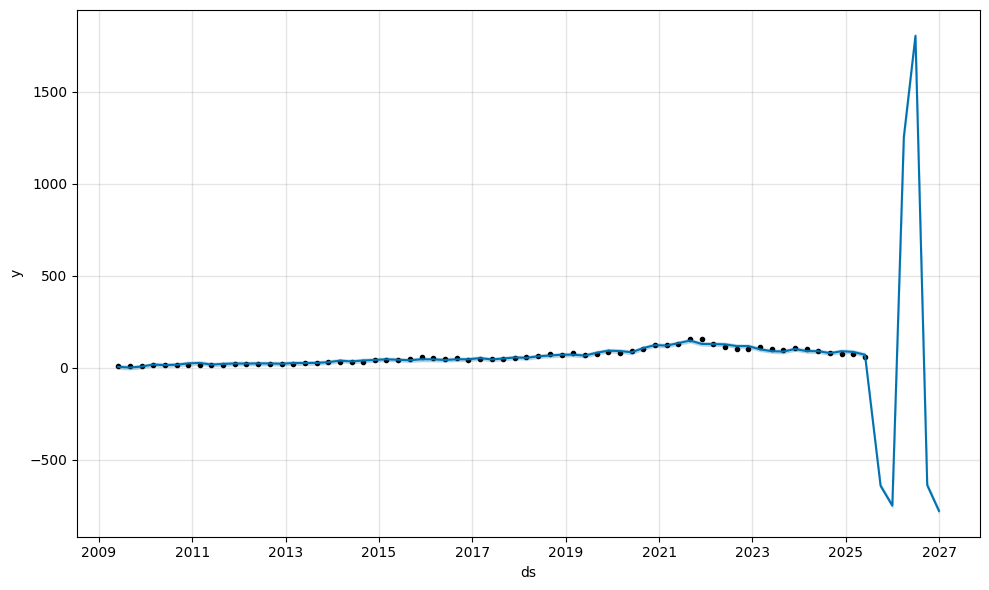

In [14]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [15]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.863777,0.954834,0.515665,0.953551,0.952809,0.634536,0.275504,0.722249
y,0.863777,1.000000,0.876411,0.613798,0.913822,0.926065,0.558404,0.291845,0.399204
revenue_musd,0.954834,0.876411,1.000000,0.674914,0.931272,0.915728,0.676562,0.296168,0.691038
net_income_musd,0.515665,0.613798,0.674914,1.000000,0.566687,0.519198,0.557589,0.210223,0.288276
total_assets_musd,0.953551,0.913822,0.931272,0.566687,1.000000,0.983743,0.724827,0.240431,0.615218
total_liabilities_musd,0.952809,0.926065,0.915728,0.519198,0.983743,1.000000,0.589321,0.172447,0.607989
share_holder_equity_musd,0.634536,0.558404,0.676562,0.557589,0.724827,0.589321,1.000000,0.420076,0.435288
gdp_growth,0.275504,0.291845,0.296168,0.210223,0.240431,0.172447,0.420076,1.000000,0.143204
interest_rate,0.722249,0.399204,0.691038,0.288276,0.615218,0.607989,0.435288,0.143204,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6998/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


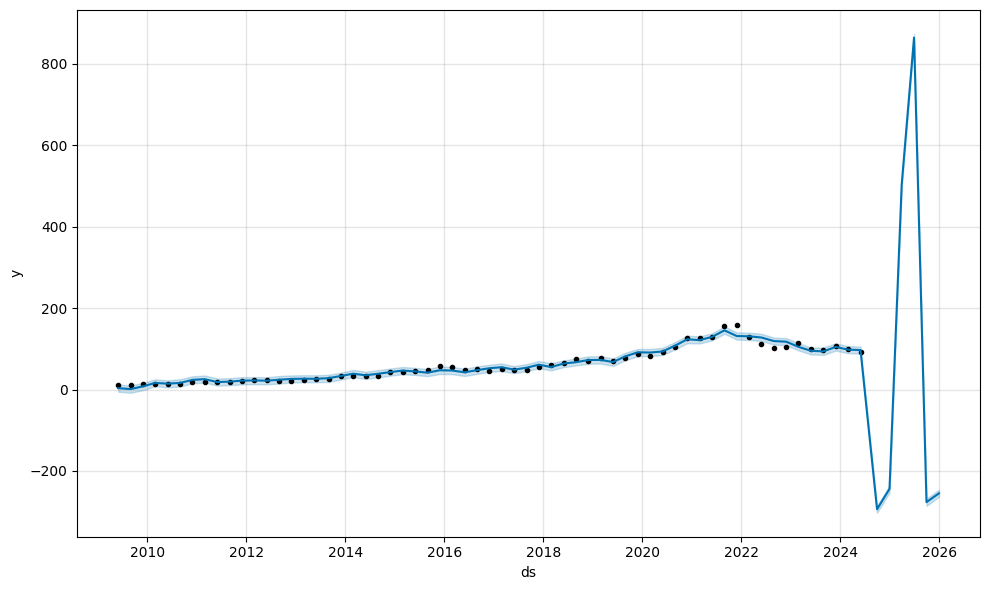

In [16]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

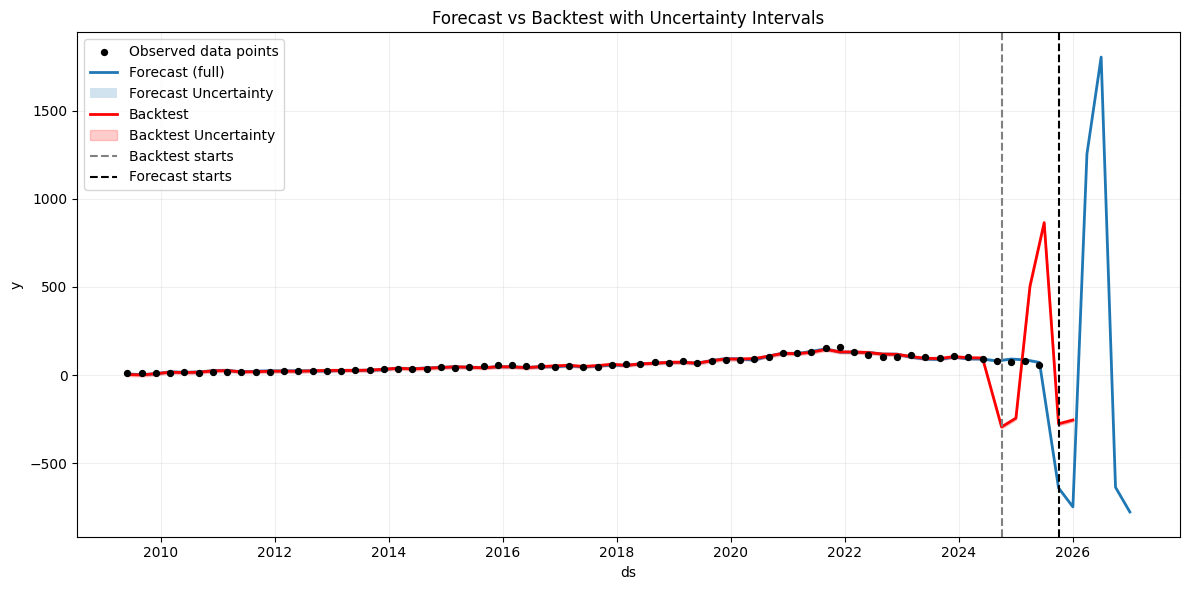

In [17]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()